In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# The adiabatic reaction temperature, and the phase of the feed (Illustration 14.3-2)

$$\mathrm{C_2H_4(g)} + \mathrm{C_6H_6(g)}\;\rightleftharpoons\;\mathrm{C_6H_5C_2H_5(g)}$$

An equimolar **gaseous** mixture of benzene and ethylene enters an adiabatic reactor at 300 K and
1 bar, and leaves in chemical equilibrium. Two conditions have to hold at once, and neither can be
solved first:

| | the condition | what it says |
|---|---|---|
| **equilibrium** | $K_a(T_{\rm ad}) = X(2-X)/(1-X)^2$ | how far the reaction *can* go at the effluent temperature |
| **energy balance** | Eq. 14.3-10a | how hot the effluent *gets* for a given extent |

Section 14.3 draws both as curves of $X$ against $T_{\rm ad}$ and takes the intersection. That is
the right picture, and solving it rather than reading it off is what this notebook does first.

Then the more interesting half. The illustration also quotes an Aspen Plus run, and it lands 60 K
cooler. That is not a data disagreement: at 300 K and 1 bar an equimolar benzene/ethylene stream is
**two-phase**, and a simulator flashes the feed it is handed while a hand calculation believes the
word *gaseous*. The second half works that difference out.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.reaction import (Reaction, reaction_cp, adiabatic_reaction_temperature,
                             energy_balance_forms_agree)
from thermo.charts import use_book_style, label_at

use_book_style()

# Ethylbenzene is "EtC6H6" in Appendix A.IV. Do NOT write "C8H10": that formula belongs
# to the three xylenes as well, and the lookup refuses an ambiguous name rather than
# guessing -- which is why this reaction names its species exactly.
rxn = Reaction.parse("C2H4 + C6H6 = EtC6H6").check_balance()
FEED = {"C2H4": 1.0, "C6H6": 1.0}
T_IN, P = 300.0, 1.0

print(f"reaction: {rxn.equation}       dnu = {rxn.delta_nu:+g}")
assert rxn.species == ["C2H4", "C6H6", "EtC6H6"], rxn.species
print(f"species:  {', '.join(rxn.species)}")

reaction: C2H4 + C6H6 = EtC6H6       dnu = -1
species:  C2H4, C6H6, EtC6H6


## The equilibrium branch

$\Delta_{\rm rxn}G^{\circ}$ and $\Delta_{\rm rxn}H^{\circ}$ at 25 °C come from Appendix A.IV,
$\Delta_{\rm rxn}C_P^{*}$ from Appendix A.II. The reaction is strongly exothermic and
$\Delta\nu = -1$, so **both** temperature and pressure push it forward -- which is why the
equilibrium curve falls to the right and why an adiabatic reactor is self-limiting here.

In [3]:
print(rxn.table([298.15]).to_string(index=False))
print(f"\ndG_rxn(25 C) = {float(rxn.delta_G_ref)/1e3:+.1f} kJ/mol"
      f"     dH_rxn(25 C) = {float(rxn.delta_H_ref)/1e3:+.1f} kJ/mol")
assert float(rxn.delta_H_ref) < 0      # exothermic, as Sec. 14.3 says after the illustration
assert rxn.delta_nu < 0

 T (K)     ln Ka  log10 Ka           Ka  dG_rxn (kJ/mol)  dH_rxn (kJ/mol)
298.15 27.148514  11.79045 6.172341e+11            -67.3           -105.5

dG_rxn(25 C) = -67.3 kJ/mol     dH_rxn(25 C) = -105.5 kJ/mol


The illustration reduces the equilibrium relation by hand. With 1 mol of each
reactant, $N_{\rm total} = 2 - X$ and

$$K_a=\frac{y_{\rm EB}}{y_{\rm E}y_{\rm B}}=\frac{X(2-X)}{(1-X)^2}
\qquad\Longrightarrow\qquad X = 1-\frac{1}{\sqrt{1+K_a}}$$

Derive that closed form rather than trust it -- it is the branch everything else is measured
against -- and check it against the general solver, which knows nothing about this stoichiometry.
 Note the radical: read as $1-1/(1+K_a)$ the expression is wrong, and near the answer below the
two readings differ by 0.2 in $X$.

In [4]:
def X_closed_form(T):
    """The illustration's own algebra."""
    return 1.0 - 1.0 / np.sqrt(1.0 + float(rxn.Ka(T)))

# Check it against the general solver, which knows nothing about this stoichiometry.
from thermo.reaction import equilibrium_extent
for T in (400.0, 588.0, 640.8, 700.0, 800.0):
    Xc = X_closed_form(T)
    Xg = float(equilibrium_extent(rxn, T, FEED, P=P).X)
    print(f"  T = {T:6.1f} K   Ka = {float(rxn.Ka(T)):11.4g}   "
          f"X(closed form) = {Xc:.6f}   X(solver) = {Xg:.6f}")
    assert abs(Xc - Xg) < 1e-8

# The misread radical, for contrast: it is not a small difference where the answer lies.
print(f"\n  at 700 K:  1 - 1/sqrt(1+Ka) = {X_closed_form(700.0):.4f}"
      f"      1 - 1/(1+Ka) = {1 - 1/(1+float(rxn.Ka(700.0))):.4f}")

  T =  400.0 K   Ka =   1.236e+07   X(closed form) = 0.999716   X(solver) = 0.999716
  T =  588.0 K   Ka =       527.8   X(closed form) = 0.956512   X(solver) = 0.956512
  T =  640.8 K   Ka =       91.69   X(closed form) = 0.896133   X(solver) = 0.896133
  T =  700.0 K   Ka =       17.75   X(closed form) = 0.769052   X(solver) = 0.769052
  T =  800.0 K   Ka =       1.948   X(closed form) = 0.417608   X(solver) = 0.417608

  at 700 K:  1 - 1/sqrt(1+Ka) = 0.7691      1 - 1/(1+Ka) = 0.9467


**The equilibrium branch and the general solver agree to machine precision**, so
the closed form above can carry the rest of the notebook. It also places the Aspen result the
illustration quotes: $y_{\rm EB} = 0.8102$ at 640.8 K corresponds to $X = 0.8951$, and the closed
form gives 0.8961 there -- agreement to 0.1 %.

**So the Aspen answer sits on the equilibrium curve.** Whatever makes it differ from the answer
below is on the *other* branch.

In [5]:
# Where the quoted Aspen result sits relative to the equilibrium branch.
X_from_y = 2 * 0.8102 / (1 + 0.8102)          # y_EB = X/(2-X)
print(f"  Aspen Plus, as quoted:  T = 640.8 K   y_EB = 0.8102  ->  X = {X_from_y:.4f}")
print(f"  the equilibrium branch at 640.8 K:                       X = {X_closed_form(640.8):.4f}")
print(f"  difference {X_from_y - X_closed_form(640.8):+.4f}  -- it lies on the curve")
assert abs(X_from_y - X_closed_form(640.8)) < 2e-3

  Aspen Plus, as quoted:  T = 640.8 K   y_EB = 0.8102  ->  X = 0.8951
  the equilibrium branch at 640.8 K:                       X = 0.8961
  difference -0.0010  -- it lies on the curve


## The energy-balance branch

Eq. 14.3-10a for an adiabatic reactor with no shaft work is

$$0=\int_{T_{\rm in}}^{T_{\rm ad}}\left(C_{P,\rm B}+C_{P,\rm E}\right)dT+\Delta_{\rm rxn}H(T_{\rm ad})\,X$$

There is a second way to write the same balance -- heat the *effluent* composition and take
$\Delta_{\rm rxn}H$ at the *inlet* -- and the two are paths between the same pair of states, so
they must give the same $X$. `energy_balance_forms_agree` asserts it instead of a comment
claiming it.

In [6]:
for T in (400.0, 500.0, 600.0, 700.0):
    a, b = energy_balance_forms_agree(rxn, FEED, T_IN, T)
    print(f"  T = {T:6.1f} K   X(total-enthalpy form) = {a:.10f}   "
          f"X(Eq. 14.3-10a form) = {b:.10f}")
print("\n  the two forms are the same equation, to machine precision")

  T =  400.0 K   X(total-enthalpy form) = 0.1398584021   X(Eq. 14.3-10a form) = 0.1398584021
  T =  500.0 K   X(total-enthalpy form) = 0.3163021008   X(Eq. 14.3-10a form) = 0.3163021008
  T =  600.0 K   X(total-enthalpy form) = 0.5252013603   X(Eq. 14.3-10a form) = 0.5252013603
  T =  700.0 K   X(total-enthalpy form) = 0.7629089742   X(Eq. 14.3-10a form) = 0.7629089742

  the two forms are the same equation, to machine precision


## The intersection

`adiabatic_reaction_temperature` brackets the search **directionally**: the reaction is
exothermic, so the effluent must be hotter than the feed, and the bracket starts one degree
above $T_{\rm in}$. That matters here -- $X_{\rm energy}(T_{\rm in}) = 0$ identically, so
$T = T_{\rm in}$ is always a root of the difference and an undirected solver can land on it and
look converged.

In [7]:
res = adiabatic_reaction_temperature(rxn, FEED, T_IN, P=P)
T_ad, X = res["T_ad"], res["X"]
y = res["y"]
print(f"  T_ad = {T_ad:.2f} K        X = {X:.4f}")
print(f"  y_B = y_E = {y['C6H6']:.4f}      y_EB = {y['EtC6H6']:.4f}")

assert abs(T_ad - 701.16) < 0.05
assert abs(X - 0.7658) < 5e-4 and abs(y["EtC6H6"] - 0.6205) < 5e-4

  T_ad = 701.16 K        X = 0.7658
  y_B = y_E = 0.1897      y_EB = 0.6205


**A bound that needs no equilibrium calculation at all.** Before going further,
ask how hot the effluent could possibly get: run the reaction to completion adiabatically and put
all of $\Delta_{\rm rxn}H$ into heating 1 mol of ethylbenzene. That is a pure enthalpy question,
and it brackets the answer above from one side.

In [8]:
from scipy.optimize import brentq
T_complete = brentq(lambda T: res["X_energy"](T) - 1.0, T_IN + 1, T_IN + 1500)
print(f"  complete conversion (X = 1) adiabatically from 300 K reaches {T_complete:.1f} K")
print(f"  the equilibrium ceiling holds the answer down to {T_ad:.1f} K at X = {X:.3f}")

cp_EB = reaction_cp("EtC6H6")
cp_at = lambda c, T: c[0] + c[1]*T + c[2]*T**2 + c[3]*T**3 + c[4]/T**2
print(f"\n  a sanity check on the scale: 1 mol of ethylbenzene at 400 K has "
      f"Cp* = {cp_at(cp_EB, 400.0):.0f} J/(mol K),")
print(f"  so {abs(float(rxn.delta_H_ref))/1e3:.1f} kJ of reaction heat can raise it by roughly "
      f"{abs(float(rxn.delta_H_ref))/cp_at(cp_EB, 400.0):.0f} K")
assert T_complete > T_ad, "complete conversion must be hotter than the equilibrium-limited answer"

  complete conversion (X = 1) adiabatically from 300 K reaches 790.4 K
  the equilibrium ceiling holds the answer down to 701.2 K at X = 0.766

  a sanity check on the scale: 1 mol of ethylbenzene at 400 K has Cp* = 171 J/(mol K),
  so 105.5 kJ of reaction heat can raise it by roughly 617 K


## The Aspen answer: the feed is not a gas at 300 K and 1 bar

The problem statement says *"an equimolar **gaseous** mixture of benzene and ethylene at 300 K."*
Check that against the vapor pressure. Benzene boils at 353 K, and at 300 K its vapor pressure is about
0.14 bar -- but in an equimolar feed at 1 bar its partial pressure would have to be 0.5 bar. So a
feed specified only by $T = 300$ K and $P = 1$ bar is **two-phase**, and most of the benzene in it
is liquid.

That is a difference between a hand calculation and a flowsheet, not a difference in data. A hand
calculation reads the word *gaseous* and takes the ideal-gas enthalpy. A process simulator handed
a temperature and a pressure flashes the stream and finds out.

Ethylene is above its critical temperature here ($T_c = 282.4$ K), so treat it as
noncondensable and put benzene's own vapor pressure in Raoult's law. Nothing below is fitted:
the flash comes from the vapor-pressure correlation, and the heat of vaporization comes from the
same correlation through Clausius-Clapeyron.

In [9]:
from thermo.data import get_compound

benz = get_compound("benzene")
Tc_B, Pc_B = float(benz["Tc"]), float(benz["Pc"])
wagner = tuple(float(benz[k]) for k in ("VpA", "VpB", "VpC", "VpD"))
assert int(benz["Eq"]) == 1, "benzene's row is not the Wagner form"

def Pvap_benzene(T):
    """Wagner equation, bar -- the constants shipped in pure_property.csv."""
    a, b, c, d = wagner
    t = 1.0 - T / Tc_B
    return Pc_B * np.exp((a*t + b*t**1.5 + c*t**3 + d*t**6) / (1.0 - t))

def dHvap_benzene(T, h=0.05, R=8.314):
    """Clausius-Clapeyron on the same correlation, J/mol. dlnP/d(1/T) = -dHvap/R."""
    return -R * (np.log(Pvap_benzene(T + h)) - np.log(Pvap_benzene(T - h))) \
             / (1.0/(T + h) - 1.0/(T - h))

# Check the correlation on two numbers it did not fit: the normal boiling point and
# the measured heat of vaporization at 298 K (33.8 kJ/mol).
T_b = brentq(lambda T: Pvap_benzene(T) - 1.01325, 300.0, 400.0)
print(f"  benzene Tb = {T_b:.1f} K (measured 353.2)      "
      f"dHvap(298 K) = {dHvap_benzene(298.15)/1e3:.1f} kJ/mol (measured 33.8)")

assert float(get_compound("ethylene")["Tc"]) < T_IN     # ethylene is noncondensable at 300 K

# Raoult flash at the stated feed conditions, per mole of ethylene.
p_B = Pvap_benzene(T_IN)
n_vap = p_B / (P - p_B)
n_liq = 1.0 - n_vap
latent = n_liq * dHvap_benzene(T_IN)
print(f"\n  benzene Pvap(300 K) = {p_B:.3f} bar, but its partial pressure in the feed is 0.500")
print(f"  -> benzene splits {n_vap:.3f} mol vapor / {n_liq:.3f} mol liquid")
print(f"  -> the reaction must supply {latent/1e3:.1f} kJ of latent heat before anything heats up")


  benzene Tb = 353.3 K (measured 353.2)      dHvap(298 K) = 34.1 kJ/mol (measured 33.8)

  benzene Pvap(300 K) = 0.138 bar, but its partial pressure in the feed is 0.500
  -> benzene splits 0.160 mol vapor / 0.840 mol liquid
  -> the reaction must supply 28.6 kJ of latent heat before anything heats up


A liquid feed enters with *less* enthalpy, so at any effluent temperature the energy balance
demands *more* extent to account for the heat that got the stream there:

$$X_{\rm energy}^{\rm 2\phi}(T)=X_{\rm energy}(T)+\frac{n_{\rm liq}\,\Delta_{\rm vap}H}
{\left|\Delta_{\rm rxn}H(T)\right|}$$

That shifts the energy-balance curve up, and because the equilibrium curve falls, the
intersection slides **left and up** -- to a cooler effluent at a higher conversion. Solve it and
compare against all three of the Aspen numbers the illustration quotes, at once.

In [10]:
def solve_two_phase(n_liq, dHvap):
    """The same two branches, with a latent load on the energy balance."""
    L = n_liq * dHvap
    X_energy_2 = lambda T: res["X_energy"](T) + L / abs(float(rxn.delta_H(T)))
    f = lambda T: res["X_equilibrium"](T) - X_energy_2(T)
    T = brentq(f, T_IN + 1.0, T_IN + 1500.0, xtol=1e-9)
    Xs = res["X_equilibrium"](T)
    return T, Xs, Xs / (2.0 - Xs)

T2, X2, y2 = solve_two_phase(n_liq, dHvap_benzene(T_IN))
print(f"  {'':26s}{'T_ad (K)':>10s}{'X':>9s}{'y_EB':>9s}")
print(f"  {'all-vapor feed (as stated)':26s}{T_ad:10.1f}{X:9.4f}{y['EtC6H6']:9.4f}")
print(f"  {'two-phase feed at 300 K':26s}{T2:10.1f}{X2:9.4f}{y2:9.4f}")
print(f"  {'Aspen Plus, as quoted':26s}{640.8:10.1f}{0.8951:9.4f}{0.8102:9.4f}")
print(f"\n  three quoted numbers recovered to {abs(T2-640.8):.1f} K and "
      f"{abs(y2-0.8102):.4f} in y_EB, from one flash calculation with nothing fitted")

# Is that agreement robust, or does it need a lucky dHvap? Vary both inputs over
# everything defensible: dHvap anywhere between its value at 300 K and at Tb, and the
# flash fraction +/- 5 %.
print(f"\n  {'sensitivity':34s}{'T_ad (K)':>10s}{'dT vs Aspen':>13s}")
for label, nl, dh in (("as derived", n_liq, dHvap_benzene(T_IN)),
                      ("dHvap measured at 298 K", n_liq, 33800.0),
                      ("dHvap measured at Tb", n_liq, 30700.0),
                      ("flash fraction -5 %", n_liq * 0.95, dHvap_benzene(T_IN)),
                      ("flash fraction +5 %", min(n_liq * 1.05, 1.0), dHvap_benzene(T_IN))):
    Ts, _, _ = solve_two_phase(nl, dh)
    print(f"  {label:34s}{Ts:10.1f}{Ts - 640.8:+13.1f}")

assert abs(T2 - 640.8) < 2.0, "the two-phase feed no longer explains the Aspen result"


                              T_ad (K)        X     y_EB
  all-vapor feed (as stated)     701.2   0.7658   0.6205
  two-phase feed at 300 K        641.1   0.8956   0.8109
  Aspen Plus, as quoted          640.8   0.8951   0.8102

  three quoted numbers recovered to 0.3 K and 0.0007 in y_EB, from one flash calculation with nothing fitted

  sensitivity                         T_ad (K)  dT vs Aspen


  as derived                             641.1         +0.3


  dHvap measured at 298 K                641.6         +0.8


  dHvap measured at Tb                   647.9         +7.1


  flash fraction -5 %                    644.6         +3.8


  flash fraction +5 %                    637.6         -3.2


**So the illustration's two answers are answers to two different problems.** The
hand calculation solves the problem as written -- a gaseous feed -- and gets 701 K. The Aspen run
solves the problem as *specified to the simulator*, 300 K and 1 bar with the phase left to the
flash, and gets 641 K. Neither is wrong arithmetic; they differ by benzene's heat of vaporization.

Two things make that an explanation rather than a story. It recovers **three** numbers from **one**
parameter that was derived, not tuned. And it survives every defensible variation of that
parameter -- worst case above is 7 K on a 60 K gap.

The direction is not the obvious one: vaporizing the feed makes the effluent **cooler** (641 K
against 701 K) and yet **more converted** (0.896 against 0.766). The latent load steals sensible
heat, the equilibrium ceiling rises as the temperature falls, and conversion gains what
temperature loses.

## Redrawing the figure

The construction stays. It shows at a glance that a hotter feed gives less conversion,
and that the equilibrium curve is the ceiling. What changes is that the curves are
computed rather than sketched, and the intersections are solved rather than read.

Each *vapor*-feed line starts at $X = 0$ when $T_{\rm ad} = T_{\rm in}$: no reaction, no
temperature rise. That anchor is what makes the family of lines readable -- a reader identifies a curve by where it
meets the axis.

### Why the two-phase curve starts at $X = 0.271$ instead

Read an energy-balance curve as the answer to *"if the effluent leaves at $T_{\rm ad}$, how much
reaction **must** have occurred?"* -- not how much *can*. At the intercept,
$T_{\rm ad} = T_{\rm in}$.

For a vapor feed that is the trivial case: nothing has changed state, no enthalpy has moved, so
$X = 0$.

For the two-phase feed it is **not** trivial, because the effluent is all vapor. Even with no
temperature rise, 0.840 mol of liquid benzene has become vapor, and that absorbs 28.6 kJ.
Adiabatic means nothing outside supplies it, so the only source is the reaction itself -- which
must therefore have run far enough to release exactly that much:

$$X_{\rm intercept}=\frac{n_{\rm liq}\,\Delta_{\rm vap}H}{\left|\Delta_{\rm rxn}H\right|}
=\frac{28.6}{105.5}=0.271$$

So the intercept is not conversion for free. It is the conversion whose entire heat release goes
into boiling the benzene, leaving nothing over to raise the temperature. That is also why the
whole curve sits *above* the vapor-feed one: at any effluent temperature you need the
sensible-heating extent **plus** the extent that pays the latent heat, and at $T = T_{\rm in}$
the sensible term vanishes and only the latent term survives.

Being a ratio of two energies makes it checkable -- the intercept is linear in how much
condensed, so half the liquid gives half the intercept. The cell below asserts that.

**The intercept is a point on one branch, not an operating state.** Like every other point on
these dashed curves it says what the energy balance permits, and nothing about whether the
reactor goes there. Equilibrium at 300 K allows $X \simeq 1$, so the intercept is far below the
ceiling; the reactor's actual answer is still the crossing at 641 K.

That is also why the two-phase case gets **one** added curve rather than replacing the family.
It is the only line here that does not start at zero, so putting it in charge would break the
anchor rule; added as one dash-dot curve, the broken anchor becomes the thing the figure teaches.


In [11]:
T_INS = [300.0, 400.0, 500.0, 600.0, 700.0, 800.0]
grid = np.linspace(300.0, 1100.0, 401)
X_eq_grid = np.array([X_closed_form(t) for t in grid])

solutions = []
for Tin in T_INS:
    r = adiabatic_reaction_temperature(rxn, FEED, Tin, P=P)
    solutions.append({"T_in (K)": Tin, "T_ad (K)": r["T_ad"], "X": r["X"],
                      "y_EB": r["y"]["EtC6H6"], "rise (K)": r["T_ad"] - Tin})
sol = pd.DataFrame(solutions)
print(sol.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

 T_in (K)  T_ad (K)    X  y_EB  rise (K)
   300.00    701.16 0.77  0.62    401.16
   400.00    726.63 0.69  0.52    326.63
   500.00    755.76 0.59  0.41    255.76
   600.00    788.24 0.46  0.30    188.24
   700.00    825.59 0.33  0.20    125.59
   800.00    871.66 0.20  0.11     71.66


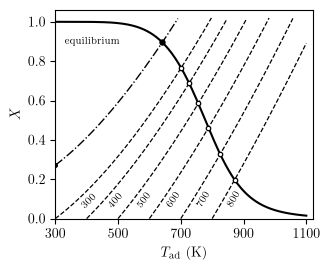

In [12]:
fig, ax = plt.subplots(figsize=(3.4, 2.8))

# Equilibrium ceiling: solid, heavier. Separated from the two energy-balance families by
# WEIGHT and DASH PATTERN, never by tint -- the art is pure black ink.
ax.plot(grid, X_eq_grid, "-", lw=1.5, color="black", zorder=3)

for Tin, row in zip(T_INS, solutions):
    r = adiabatic_reaction_temperature(rxn, FEED, Tin, P=P)
    tt = np.linspace(Tin, 1100.0, 300)
    xx = np.array([r["X_energy"](t) for t in tt])
    keep = xx <= 1.02
    ax.plot(tt[keep], xx[keep], "--", lw=0.9, color="black", zorder=2)
    ax.plot([row["T_ad (K)"]], [row["X"]], "o", ms=3.2, mfc="white", mec="black",
            mew=0.9, zorder=4)

# The same 300 K feed with its phase NOT assumed. Dash-dot, and it is the one curve in
# the family that does not start at X = 0: at T_ad = T_in the reaction has still had to
# boil 0.840 mol of benzene, so X(300 K) = 0.271. That nonzero intercept is the whole
# point of the curve, so the axes must start at exactly X = 0 for it to be visible.
X_energy_2phase = lambda T: res["X_energy"](T) + latent / abs(float(rxn.delta_H(T)))
tt = np.linspace(T_IN, 1100.0, 300)
xx = np.array([X_energy_2phase(t) for t in tt])
keep = xx <= 1.02
ax.plot(tt[keep], xx[keep], "-.", lw=1.0, color="black", zorder=2)
ax.plot([T_IN], [X_energy_2phase(T_IN)], "o", ms=2.6, mfc="black", mec="black", zorder=5)
# Filled marker, so the two-phase solution is not read as a seventh vapor-feed answer.
ax.plot([T2], [X2], "o", ms=3.6, mfc="black", mec="black", zorder=5)

ax.set_xlim(300, 1120); ax.set_ylim(0, 1.06)
ax.set_xlabel(r"$T_{\rm ad}$ (K)"); ax.set_ylabel(r"$X$")
ax.set_xticks([300, 500, 700, 900, 1100])

# ONE region label inside the axes. The three-curve legend goes in the CAPTION instead:
# at 3.4 in there is no empty region left that fits "two-phase feed" or "feed
# temperature (K)" without crossing a curve, and masking a curve to place a label is
# worse than moving the label off the plot.
ax.text(330, 0.90, "equilibrium", fontsize=7, ha="left", va="center")

# --- the feed temperatures, angled along their own curves ---------------------
# tight_layout FIRST: it resizes the axes box, and the axes box is what sets the
# data -> display transform that the rotation angle is computed from. Angles measured
# before this call would be wrong by however much the box moved.
fig.tight_layout()

def curve_angle(fn, T, dT=2.0):
    """Slope of a curve at T in DISPLAY degrees.

    NOT the data-space slope. x spans 820 K and y spans 1.06 over an axes box that is
    neither square nor unit-aspect, so dX/dT says nothing about the angle a reader
    sees. Transform two nearby points and measure the angle between them.
    """
    x0, y0 = ax.transData.transform((T, fn(T)))
    x1, y1 = ax.transData.transform((T + dT, fn(T + dT)))
    return np.degrees(np.arctan2(y1 - y0, x1 - x0))

X_LABEL = 0.12          # ride each curve high enough that the perpendicular offset
                        # below does not push the type into the spine or the ticks
for Tin in T_INS:
    r = adiabatic_reaction_temperature(rxn, FEED, Tin, P=P)
    T_lab = brentq(lambda t: r["X_energy"](t) - X_LABEL, Tin, Tin + 400.0)
    ang = curve_angle(r["X_energy"], T_lab)
    # Offset PERPENDICULAR to the curve, in points rather than in data units, so the
    # clearance is the same for every curve however steep it is. For a curve rising to
    # the right the outward normal is (sin, -cos): down and to the right, into the
    # empty wedge below the curve rather than across it.
    nx, ny = np.sin(np.radians(ang)), -np.cos(np.radians(ang))
    ax.annotate(f"{Tin:.0f}", xy=(T_lab, X_LABEL),
                xytext=(6.5 * nx, 6.5 * ny), textcoords="offset points",
                fontsize=7, rotation=ang, rotation_mode="anchor",
                ha="center", va="center")

plt.show()

In [13]:
# The intercept is L / |dH_rxn| -- a ratio of two energies, so it is linear in how much
# of the benzene condensed. Assert that rather than assert it in prose.
dH_300 = abs(float(rxn.delta_H(T_IN)))
intercept = lambda n_l: n_l * dHvap_benzene(T_IN) / dH_300

print(f"  |dH_rxn(300 K)| = {dH_300/1e3:.1f} kJ/mol")
print(f"  X_energy(300 K), vapor feed        = {abs(res['X_energy'](T_IN)):.3f}   (identically zero)")
print(f"  X_energy(300 K), two-phase feed    = {intercept(n_liq):.3f}"
      f"   = {latent/1e3:.1f}/{dH_300/1e3:.1f}\n")
for n_l, label in ((n_liq, "the flash, 0.840 mol liquid"),
                   (n_liq / 2, "half as much condensed"),
                   (1.0, "all 1.0 mol liquid")):
    print(f"  {label:28s} n_liq = {n_l:.3f}   intercept = {intercept(n_l):.3f}")

# linear in n_liq, and it must agree with the curve the figure actually drew
assert abs(intercept(n_liq / 2) - intercept(n_liq) / 2) < 1e-12
assert abs(intercept(n_liq) - X_energy_2phase(T_IN)) < 1e-12
print("\n  linear in the condensed fraction, and equal to the plotted curve's intercept")


  |dH_rxn(300 K)| = 105.5 kJ/mol
  X_energy(300 K), vapor feed        = 0.000   (identically zero)
  X_energy(300 K), two-phase feed    = 0.271   = 28.6/105.5

  the flash, 0.840 mol liquid  n_liq = 0.840   intercept = 0.271
  half as much condensed       n_liq = 0.420   intercept = 0.136
  all 1.0 mol liquid           n_liq = 1.000   intercept = 0.323

  linear in the condensed fraction, and equal to the plotted curve's intercept


The **open** circles are the vapor-feed solutions, and they are the primary content of
the figure: raising the feed temperature from 300 K to 800 K moves the effluent from 701 K to
872 K while dropping the conversion from 0.766 to 0.205. A hotter feed is worse, and it is worse
twice over -- less conversion *and* a hotter stream to cool down afterwards.

The **filled** circles belong to the dash-dot curve, and they are deliberately a different
marker so the 641 K point is not read as a seventh vapor-feed answer. The small one on the axis
is that curve's intercept, $X = 0.271$; the large one is the two-phase solution, where the same
300 K feed lands once its phase is not assumed.

**The figure now needs its caption to carry the legend**, because there is no empty region
left at 3.4 in that fits "two-phase feed" or "feed temperature (K)" without crossing a curve:

> Solid curve: chemical equilibrium. Dashed curves: the energy balance for a **vapor** feed,
> each labeled by its feed temperature in K, with open circles at the adiabatic solutions.
> Dash-dot curve: the energy balance for the **two-phase** feed at 300 K and 1 bar, with filled
> circles at its intercept and its solution.

## Staging the art

Drawn at the width it is printed at -- 3.4 in, one column -- so 7 pt in the notebook is 7 pt on
the page.

    pdf/Figure_14.3-2.pdf   ->   deliverables/figures/print-bw/ch14/c14uf002.pdf

In [14]:
import os
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_14.3-2.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'} Computer Modern")

  wrote pdf/Figure_14.3-2.pdf
  typography: LaTeX Computer Modern


## Your turn

1. The illustration's closed form is $X = 1 - 1/\sqrt{1+K_a}$, and $X$ therefore depends on
   $K_a$ **only** -- pressure never appears, even though $\Delta\nu = -1$. Work out why from the
   stoichiometric table, then check it: run the calculation at 10 bar and at 0.1 bar and report
   $T_{\rm ad}$ to two decimals. What feature of *this* feed makes the pressure drop out, and
   what would break it?
2. Add nitrogen as an inert -- say 1, 4 and 10 mol of it per mole of feed -- and report
   $T_{\rm ad}$ and $X$ for each. The inert changes **both** branches, and in opposite
   directions. Separate the two effects numerically before you explain them, and say which one
   wins.
3. The two-phase feed explains the Aspen answer with a latent heat, so test whether property
   data could have explained it instead. Redo the all-vapor calculation with the heat capacities
   from `pure_property.csv` (the Reid, Prausnitz and Poling set) in place of Appendix A.II, and
   then again with the formation enthalpies perturbed by 1 kJ/mol each -- the most any two modern
   databanks disagree on these three species. How far does $T_{\rm ad}$ move in each case, and
   how does that compare with the 60 K the phase change is worth?
4. Raise the feed temperature until the flash disappears. At what $T_{\rm in}$ does benzene's
   partial pressure of 0.5 bar stop condensing, and what are $T_{\rm ad}$ and $X$ for a
   *saturated-vapor* feed at exactly that temperature? Compare that answer with both of the
   illustration's, and say which feed specification you would put in the problem statement.
5. `adiabatic_reaction_temperature` brackets from $T_{\rm in} + 1$ K upward because the reaction
   is exothermic. Remove the guard: bracket from $T_{\rm in}$ instead and see what root you get.
   Then construct a case where the undirected bracket returns the wrong answer *silently* rather
   than failing, and explain why a converged root is not evidence of a correct one.
6. Sec. 14.3 says an endothermic reaction gives "mirror images" of these curves (see Problem
   14.13). Run one -- nitrogen + oxygen $\rightarrow$ 2 NO, feed at 3000 K, which is
   Problem 14.13 -- and say what the mirroring does and does not reverse. Which of the two
   curves changes slope, and which changes only its anchor?